# Importing Lib



In [1]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [3]:
import pandas as pd

data = pd.read_csv(
    '/kaggle/input/datasets/luyucwnu/tlmuav-anomaly-detection-datasets/dataset/RATE/ALL_FAIL_LOG_RATE.csv')

print(data.shape)
print(data.columns.tolist())
data.head()

(4900, 15)
['LineNO', 'TimeUS', 'RDes', 'R', 'Rout', 'PDes', 'P', 'POut', 'YDes', 'Y', 'YOut', 'ADes', 'A', 'AOut', 'labels']


,LineNO,TimeUS,RDes,R,Rout,PDes,P,POut,YDes,Y,YOut,ADes,A,AOut,labels
0,1715,15363852,-0.080699,0.008877,-0.000223,-0.032351,0.005687,-0.000096,0.000005,1.377302,-0.002177,0.476742,0.476742,0.0,0
1,1797,15463812,-0.080392,0.009570,-0.000201,-0.033152,0.008595,-0.000117,0.000007,1.358535,-0.002151,0.450039,0.450039,0.0,0
2,1876,15563772,-0.080012,0.009819,-0.000219,-0.034111,0.007455,-0.000108,0.000009,1.342084,-0.002124,0.458717,0.458717,0.0,0
3,1955,15663732,-0.080031,0.008554,-0.000202,-0.034064,0.004384,-0.000102,0.000008,1.323240,-0.002100,0.533676,0.533676,0.0,0
4,2034,15763692,-0.079839,0.011863,-0.000230,-0.034537,0.010646,-0.000125,0.000003,1.310079,-0.002073,0.459576,0.459576,0.0,0


# Preprocessing and Exploring data



In [4]:
print("Dataset Shape:", data.shape)
print("\nColumns:\n", data.columns)
print("\nSample Data:\n", data.head())
print("\nMissing Values:\n", data.isnull().sum())

Dataset Shape: (4900, 15)

Columns:
 Index(['LineNO', 'TimeUS', 'RDes', 'R', 'Rout', 'PDes', 'P', 'POut', 'YDes',
       'Y', 'YOut', 'ADes', 'A', 'AOut', 'labels'],
      dtype='object')

Sample Data:
    LineNO    TimeUS      RDes         R      Rout      PDes         P  \
0    1715  15363852 -0.080699  0.008877 -0.000223 -0.032351  0.005687   
1    1797  15463812 -0.080392  0.009570 -0.000201 -0.033152  0.008595   
2    1876  15563772 -0.080012  0.009819 -0.000219 -0.034111  0.007455   
3    1955  15663732 -0.080031  0.008554 -0.000202 -0.034064  0.004384   
4    2034  15763692 -0.079839  0.011863 -0.000230 -0.034537  0.010646   

       POut      YDes         Y      YOut      ADes         A  AOut  labels  
0 -0.000096  0.000005  1.377302 -0.002177  0.476742  0.476742   0.0       0  
1 -0.000117  0.000007  1.358535 -0.002151  0.450039  0.450039   0.0       0  
2 -0.000108  0.000009  1.342084 -0.002124  0.458717  0.458717   0.0       0  
3 -0.000102  0.000008  1.323240 -0.002100  0.5

In [5]:
print("\nData Types:\n", data.dtypes)


Data Types:
 LineNO      int64
TimeUS      int64
RDes      float64
R         float64
Rout      float64
PDes      float64
P         float64
POut      float64
YDes      float64
Y         float64
YOut      float64
ADes      float64
A         float64
AOut      float64
labels      int64
dtype: object


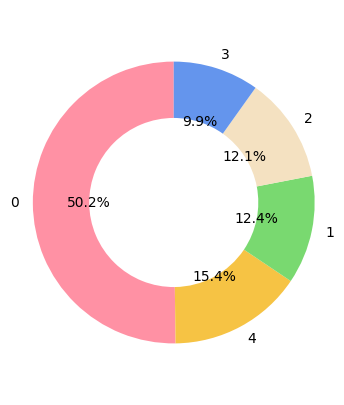

In [6]:

if 'labels' in data.columns:
    label_counts = data['labels'].value_counts()
    # Define specific colors for 5 labels
    colors = ["#FF91A4", "#f6c344", "#79d970", "#F4E1C1", "#6495ED"]

    # Plot the donut chart
    plt.figure(figsize=(4, 5))
    plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'width': 0.4})
    plt.axis('equal')
    plt.show()



In [7]:
# Encoding Categorical Data
if 'labels' in data.columns:
    label_encoder = LabelEncoder()
    data['labels'] = label_encoder.fit_transform(data['labels'])
    print("\nLabel Encoding Complete. Classes:", label_encoder.classes_)


Label Encoding Complete. Classes: [0 1 2 3 4]


In [8]:
# Feature Selection
X = data.drop(columns=['labels']).values  # Features
y = data['labels'].values  # Target

In [9]:
X.shape

(4900, 14)

In [10]:
# Scaling Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# One-hot encode the labels
# One-hot encode the labels
y_encoded = to_categorical(y, num_classes=len(np.unique(y)))

In [15]:
window_size = 5

X_windows = []
y_windows = []

for i in range(len(X_scaled) - window_size + 1):
    X_windows.append(X_scaled[i:i+window_size])
    y_windows.append(y_encoded[i + window_size - 1])   # ✅ Correct

X_windows = np.array(X_windows)
y_windows = np.array(y_windows)

print(X_windows.shape)
print(y_windows.shape)

input_shape = X_windows.shape[1:]
num_classes = y_windows.shape[1]

(4896, 5, 14)
(4896, 5)


In [16]:
X_windows.shape

(4896, 5, 14)

In [17]:
for label in data['labels'].unique():
    print(f"\nValues for label: {label}")
    print(data[data['labels'] == label].head())


Values for label: 0
   LineNO    TimeUS      RDes         R      Rout      PDes         P  \
0    1715  15363852 -0.080699  0.008877 -0.000223 -0.032351  0.005687   
1    1797  15463812 -0.080392  0.009570 -0.000201 -0.033152  0.008595   
2    1876  15563772 -0.080012  0.009819 -0.000219 -0.034111  0.007455   
3    1955  15663732 -0.080031  0.008554 -0.000202 -0.034064  0.004384   
4    2034  15763692 -0.079839  0.011863 -0.000230 -0.034537  0.010646   

       POut      YDes         Y      YOut      ADes         A  AOut  labels  
0 -0.000096  0.000005  1.377302 -0.002177  0.476742  0.476742   0.0       0  
1 -0.000117  0.000007  1.358535 -0.002151  0.450039  0.450039   0.0       0  
2 -0.000108  0.000009  1.342084 -0.002124  0.458717  0.458717   0.0       0  
3 -0.000102  0.000008  1.323240 -0.002100  0.533676  0.533676   0.0       0  
4 -0.000125  0.000003  1.310079 -0.002073  0.459576  0.459576   0.0       0  

Values for label: 1
     LineNO     TimeUS       RDes         R      Ro

# Model

In [18]:
# Define the TCN Block
def TCN_Block(filters, kernel_size, dilation_rate):
    return tf.keras.Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size, padding='causal', dilation_rate=dilation_rate),
        BatchNormalization(),
        Activation('relu')
    ])

In [19]:
# Define the Attention Layer
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],), initializer="zeros", trainable=True)
        self.u = self.add_weight(shape=(input_shape[-1],), initializer="glorot_uniform", trainable=True)

    def call(self, inputs):
        u_t = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a_t = tf.nn.softmax(tf.tensordot(u_t, self.u, axes=1), axis=1)
        output = tf.reduce_sum(inputs * tf.expand_dims(a_t, -1), axis=1)
        return output

In [20]:
# Define the TCN with Attention Model
def build_tcn_attention_model(input_shape, num_classes):
    # inputs = Input(shape=input_shape)
# def build_tcn_attention_model(X_windows, num_classes):
    inputs = Input(shape=input_shape)
     # Replacing input_shape with X_windows.shape
    # TCN Layers
    x = TCN_Block(filters=64, kernel_size=3, dilation_rate=4)(inputs)
    x = TCN_Block(filters=64, kernel_size=3, dilation_rate=8)(x)
    x = TCN_Block(filters=64, kernel_size=3, dilation_rate=16)(x)

    # Attention mechanism
    attention_output = AttentionLayer()(x)

    # Classification
    classification = Dense(num_classes, activation='softmax')(attention_output)

    # Define and compile the model
    model = Model(inputs=inputs, outputs=classification)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss=categorical_crossentropy,
                  metrics=['accuracy'])

    return model


In [29]:
# input_shape
X_windows.shape[2]

14

In [30]:
X_windows.shape[1]

5

In [31]:
X_windows.shape[0]

4896

In [23]:
X_windows.shape

(21597, 1, 16)

In [21]:
# Input shape for TCN
input_shape = (X_windows.shape[1], X_windows.shape[2])
num_classes = y_windows.shape[1]

In [23]:
# Perform k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
accuraciesKF = []
label_accuraciesKF = []

for train_index, val_index in kf.split(X_windows):
    print(f"\nTraining fold {fold_no}...")

    # Split data
    X_train_foldKF, X_val_foldKF = X_windows[train_index], X_windows[val_index]
    y_train_foldKF, y_val_foldKF = y_windows[train_index], y_windows[val_index]

    # Build and train the model
    # modelKF = build_tcn_attention_model(input_shape, num_classes)

    # Build and train the model
    # modelKF = build_tcn_attention_model(input_shape, num_classes)
    modelKF = build_tcn_attention_model(input_shape, num_classes)
    modelKF.fit(X_train_foldKF, y_train_foldKF, epochs=50, batch_size=32, verbose=0, validation_data=(X_val_foldKF, y_val_foldKF))
   

    # Evaluate the model
    lossKF, accuracyKF = modelKF.evaluate(X_val_foldKF, y_val_foldKF, verbose=0)
    print(f"Validation Accuracy for fold {fold_no}: {accuracyKF:.4f}")
    accuraciesKF.append(accuracyKF)

    # Predictions
    y_predKF = modelKF.predict(X_val_foldKF)
    y_pred_classesKF = np.argmax(y_predKF, axis=1)
    y_true_classesKF = np.argmax(y_val_foldKF, axis=1)

    # Accuracy per label
    label_accKF = []
    for label in range(num_classes):
        label_indicesKF = (y_true_classesKF == label)
        label_accKF.append(accuracy_score(y_true_classesKF[label_indicesKF], y_pred_classesKF[label_indicesKF]))
    label_accuraciesKF.append(label_accKF)

    fold_no += 1



Training fold 1...


2026-07-03 09:31:30.453437: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Validation Accuracy for fold 1: 0.9918
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Training fold 2...
Validation Accuracy for fold 2: 0.9765
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Training fold 3...
Validation Accuracy for fold 3: 0.9806
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Training fold 4...
Validation Accuracy for fold 4: 0.9969
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Training fold 5...
Validation Accuracy for fold 5: 0.9837
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [24]:
modelKF.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 5, 14)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 5, 64)          │         3,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_13 (Sequential)      │ (None, 5, 64)          │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_14 (Sequential)      │ (None, 5, 64)          │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_4               │ (None, 64)             │         4,224 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,553 (381.07 KB)

 Trainable params: 32,389 (126.52 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 64,780 (253.05 KB)

In [25]:
# Calculate average accuracy
average_accuracyKF = np.mean(accuraciesKF)
print(f"\nAverage Accuracy across all folds: {average_accuracyKF:.4f}")


Average Accuracy across all folds: 0.9859


In [26]:
# Average accuracy per label
label_accuraciesKF = np.mean(label_accuraciesKF, axis=0)
for idx, acc in enumerate(label_accuraciesKF):
    print(f"Label {idx} Accuracy: {acc:.4f}")

Label 0 Accuracy: 0.9832
Label 1 Accuracy: 0.9720
Label 2 Accuracy: 0.9942
Label 3 Accuracy: 0.9937
Label 4 Accuracy: 0.9929


In [32]:
# Evaluate the last fold predictions
y_predKF = modelKF.predict(X_val_foldKF)
y_pred_classesKF = np.argmax(y_predKF, axis=1)
y_true_classesKF = np.argmax(y_val_foldKF, axis=1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [35]:
import pandas as pd
import numpy as np


feature_names = ['LineNO', 'TimeUS', 'RDes', 'R', 'Rout', 'PDes', 'P', 'POut', 'YDes',
       'Y', 'YOut', 'ADes', 'A', 'AOut']


# Step 1: Get Model Predictions
y_pred_probs = modelKF.predict(X_windows, verbose=0)

# Convert probabilities to labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_windows, axis=1)

# Find misclassified windows
mismatch_indices = np.where(y_true_labels != y_pred_labels)[0]

print("Total Misclassified Windows:", len(mismatch_indices))

# Extract the last time step from each misclassified window
X_last = X_windows[mismatch_indices, -1, :]

# Create DataFrame
df_mismatches = pd.DataFrame(
    X_last,
    columns=feature_names
)

# Add labels
df_mismatches["Actual_Label"] = y_true_labels[mismatch_indices]
df_mismatches["Predicted_Label"] = y_pred_labels[mismatch_indices]

# Add original window index
df_mismatches.insert(0, "Window_Index", mismatch_indices)

print(df_mismatches)

# Optional: Save to CSV
df_mismatches.to_csv("Misclassified_Windows.csv", index=False)




Total Misclassified Windows: 55
    Window_Index    LineNO    TimeUS      RDes         R      Rout      PDes  \
0            751 -1.196720 -1.187654  0.473204 -1.425643  1.345451  0.006989   
1            752 -1.196003 -1.186952 -0.021663  1.358117 -1.158413 -0.367724   
2            753 -1.195279 -1.186249  0.425291 -1.347131  1.150537 -0.888989   
3            754 -1.194571 -1.185546 -0.178926  1.308592 -0.948358 -1.470486   
4            799 -1.162669 -1.153918  0.422024 -0.837760  0.137603 -0.262092   
5            800 -1.161968 -1.153216 -0.025790  0.830812 -0.092417  0.047435   
6            801 -1.161252 -1.152513  0.466919 -0.947525  0.314717 -0.174335   
7            802 -1.160544 -1.151811 -0.100910  0.924497 -0.246150 -0.344570   
8            817 -1.149886 -1.141266  0.205319 -0.535250 -0.231399 -0.201991   
9            818 -1.149194 -1.140564 -0.023450  0.218805  0.540868  0.923137   
10           819 -1.148493 -1.139861  0.364061 -0.370461 -0.396434  0.810325   
11      

In [38]:
import pandas as pd
import numpy as np

feature_names = [
    'LineNO', 'TimeUS', 'RDes', 'R', 'Rout',
    'PDes', 'P', 'POut', 'YDes', 'Y',
    'YOut', 'ADes', 'A', 'AOut'
]

# Predictions
y_pred_probs = modelKF.predict(X_windows, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_windows, axis=1)

# Misclassified windows
mismatch_indices = np.where(y_true_labels != y_pred_labels)[0]

# Take only the last time step
X_last = X_windows[mismatch_indices, -1, :]

df_mismatches = pd.DataFrame(
    X_last,
    columns=feature_names
)

df_mismatches.insert(0, "Window_Index", mismatch_indices)
df_mismatches["Actual_Label"] = y_true_labels[mismatch_indices]
df_mismatches["Predicted_Label"] = y_pred_labels[mismatch_indices]

print(df_mismatches)

    Window_Index    LineNO    TimeUS      RDes         R      Rout      PDes  \
0            751 -1.196720 -1.187654  0.473204 -1.425643  1.345451  0.006989   
1            752 -1.196003 -1.186952 -0.021663  1.358117 -1.158413 -0.367724   
2            753 -1.195279 -1.186249  0.425291 -1.347131  1.150537 -0.888989   
3            754 -1.194571 -1.185546 -0.178926  1.308592 -0.948358 -1.470486   
4            799 -1.162669 -1.153918  0.422024 -0.837760  0.137603 -0.262092   
5            800 -1.161968 -1.153216 -0.025790  0.830812 -0.092417  0.047435   
6            801 -1.161252 -1.152513  0.466919 -0.947525  0.314717 -0.174335   
7            802 -1.160544 -1.151811 -0.100910  0.924497 -0.246150 -0.344570   
8            817 -1.149886 -1.141266  0.205319 -0.535250 -0.231399 -0.201991   
9            818 -1.149194 -1.140564 -0.023450  0.218805  0.540868  0.923137   
10           819 -1.148493 -1.139861  0.364061 -0.370461 -0.396434  0.810325   
11           820 -1.147800 -1.139158 -0.

In [40]:
# Step 1: Identify correctly classified windows
correct_indices = np.where(y_true_labels == y_pred_labels)[0]

# Step 2: Extract the last time step of each correctly classified window
X_last = X_windows[correct_indices, -1, :]

# Step 3: Create DataFrame
df_correct = pd.DataFrame(
    X_last,
    columns=feature_names
)

# Add metadata
df_correct.insert(0, "Window_Index", correct_indices)
df_correct["Actual_Label"] = y_true_labels[correct_indices]
df_correct["Predicted_Label"] = y_pred_labels[correct_indices]

# Step 4: Save to CSV
df_correct.to_csv("correctly_classified.csv", index=False)

# Display
print(df_correct.head())

   Window_Index    LineNO    TimeUS      RDes         R      Rout      PDes  \
0             0 -1.717969 -1.829369  0.199898 -0.026947  0.064477 -0.058560   
1             1 -1.717332 -1.828666  0.199905 -0.026971  0.064525 -0.058579   
2             2 -1.716702 -1.827964  0.199920 -0.027006  0.064531 -0.058618   
3             3 -1.716073 -1.827261  0.199924 -0.026926  0.064477 -0.058628   
4             4 -1.715451 -1.826559  0.198677 -0.026973  0.064349 -0.059254   

          P      POut      YDes         Y      YOut      ADes         A  \
0  0.042534 -0.087886 -0.050441  0.078761 -0.106292 -0.265099  0.395857   
1  0.042506 -0.087856 -0.050441  0.078639 -0.106170 -0.265143  0.395760   
2  0.042491 -0.087852 -0.050441  0.078485 -0.106053 -0.265193  0.395648   
3  0.042475 -0.087826 -0.050441  0.078375 -0.105942 -0.265070  0.395922   
4  0.042470 -0.087910 -0.050441  0.078250 -0.105824 -0.265165  0.395710   

       AOut  Actual_Label  Predicted_Label  
0 -1.827854             0    

In [41]:
df_mismatches.to_csv("misclassified_samples.csv", index=False)
print("CSV file 'misclassified_samples.csv' saved successfully!")


CSV file 'misclassified_samples.csv' saved successfully!


In [42]:
# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true_classesKF, y_pred_classesKF,digits = 4))


Classification Report:

              precision    recall  f1-score   support

           0     0.9722    0.9959    0.9839       491
           1     1.0000    0.9098    0.9528       122
           2     1.0000    0.9907    0.9953       107
           3     1.0000    0.9904    0.9952       104
           4     0.9872    0.9935    0.9904       155

    accuracy                         0.9837       979
   macro avg     0.9919    0.9761    0.9835       979
weighted avg     0.9840    0.9837    0.9835       979




Label Distribution:
 labels
0    10147
4     3440
2     3092
1     2846
3     2072
Name: count, dtype: int64


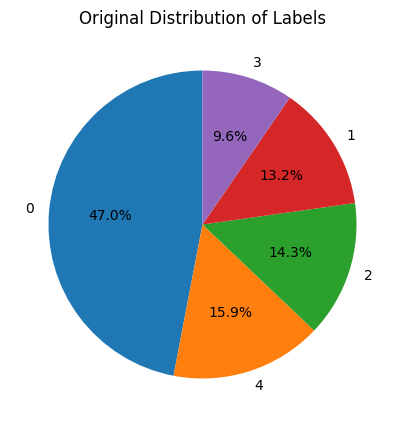

In [36]:
if 'labels' in data.columns:
    label_countsKF = data['labels'].value_counts()
    print("\nLabel Distribution:\n", label_countsKF)
    plt.figure(figsize=(5, 5))
    plt.pie(label_countsKF, labels=label_countsKF.index, autopct='%1.1f%%', startangle=90)
    plt.title('Original Distribution of Labels')
    plt.show()

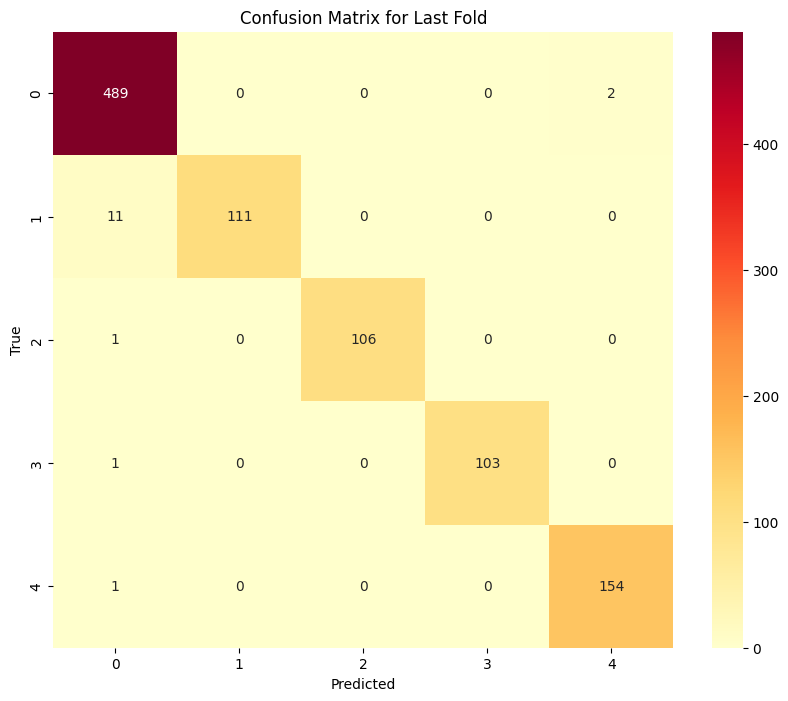

In [43]:
# Confusion Matrix
conf_matrixKF = tf.math.confusion_matrix(y_true_classesKF, y_pred_classesKF)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrixKF, annot=True, fmt='d', cmap='YlOrRd')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.title('Confusion Matrix for Last Fold')
plt.show()

In [1]:

# Get the label distribution after training
# Get the predicted labels after training
class_counts = pd.Series(y_pred_classesKF).value_counts()
print(class_counts)
# Plot pie chart of predicted labels
plt.figure(figsize=(4, 5))
colors = ["#FF91A4", "#f6c344", "#79d970", "#F4E1C1", "#6495ED"]
plt.pie(pd.Series(y_pred_classesKF).value_counts(), labels=label_encoder.classes_, autopct='%1.1f%%', startangle=90,colors=colors)
plt.axis('equal')
plt.title('TCN-A predicted Label distribution on RATE Dataset')
plt.show()

NameError: name 'pd' is not defined